# Implementasi Algoritma Random Forest untuk Prediksi Tingkat Burnout pada Mahasiswa Berdasarkan Faktor Akademik dan Gaya Hidup

Penelitian ini bertujuan untuk membangun model klasifikasi untuk memprediksi tingkat burnout mahasiswa menggunakan algoritma Random Forest.

## SECTION 1: Dataset Collection

Import library yang diperlukan dan memuat dataset dari direktori `/content/sample_data/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Load dataset
file_path = '/content/sample_data/student_mental_health_burnout_100k_fixed.xlsx'
df = pd.read_excel(file_path)
print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


## SECTION 2: Dataset Understanding

Melihat struktur data, statistik deskriptif, dan distribusi target.

Shape dataset: (100000, 17)
Jumlah data: 100000
Jumlah fitur: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   academic_year         100000 non-null  int64  
 3   study_hours_per_day   100000 non-null  float64
 4   exam_pressure         100000 non-null  int64  
 5   academic_performance  100000 non-null  float64
 6   stress_level          100000 non-null  int64  
 7   anxiety_score         100000 non-null  int64  
 8   depression_score      100000 non-null  int64  
 9   sleep_hours           100000 non-null  float64
 10  physical_activity     100000 non-null  float64
 11  social_support        100000 non-null  object 
 12  screen_time           100000 non-null  float64
 13  internet_usage        100000 non-null  f

None

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,screen_time,internet_usage,financial_stress,family_expectation
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,20.997990,2.495760,6.970176,5.976900,2.998325,5.677520,10.168670,10.289200,6.378363,2.910541,4.298316,5.099248,5.49896,5.493660
std,1.999221,1.120069,1.587647,2.011499,0.265844,1.084951,2.214527,2.070557,0.837401,1.386300,1.475497,1.804410,2.22088,2.223077
min,18.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,1.00000,1.000000
25%,19.000000,1.000000,5.900000,5.000000,2.820000,5.000000,9.000000,9.000000,5.800000,1.900000,3.300000,3.900000,4.00000,4.000000
50%,21.000000,2.000000,7.000000,6.000000,3.000000,6.000000,10.000000,10.000000,6.400000,2.900000,4.300000,5.100000,5.00000,5.000000
75%,23.000000,3.000000,8.000000,7.000000,3.180000,6.000000,12.000000,12.000000,6.900000,3.900000,5.300000,6.300000,7.00000,7.000000
max,24.000000,4.000000,12.000000,10.000000,4.000000,10.000000,20.000000,20.000000,9.000000,6.000000,8.000000,10.000000,10.00000,10.000000


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_level
0,18,Female,2,6.5,4,2.84,6,10,11,4.7,2.8,Medium,2.2,4.4,8,3,Low
1,23,Male,4,6.6,9,2.64,7,13,14,6.0,2.5,Medium,6.8,7.9,7,10,High
2,22,Female,4,7.2,8,2.73,5,9,9,7.0,2.5,High,2.7,1.7,5,4,Medium
3,21,Male,4,8.5,8,3.70,5,10,8,6.2,3.2,Medium,2.2,2.4,1,4,Medium
4,21,Female,4,5.9,7,2.41,6,10,11,6.0,2.6,High,3.2,4.8,8,6,Medium


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_level
99995,24,Male,1,7.0,5,3.75,4,7,7,7.0,2.3,Medium,3.9,3.0,1,4,Low
99996,18,Female,4,7.1,8,2.84,7,13,13,7.8,1.0,Low,4.4,3.8,3,8,High
99997,22,Male,1,7.3,7,3.17,6,11,13,5.4,3.0,Medium,3.4,6.4,5,8,Medium
99998,18,Male,2,10.3,3,3.29,4,7,5,7.1,4.5,Low,2.3,4.4,3,2,Low
99999,24,Female,1,5.8,9,2.37,7,13,12,7.1,1.8,Medium,5.4,7.4,4,7,High


/tmp/ipykernel_974/3209872394.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='burnout_level', palette='viridis')


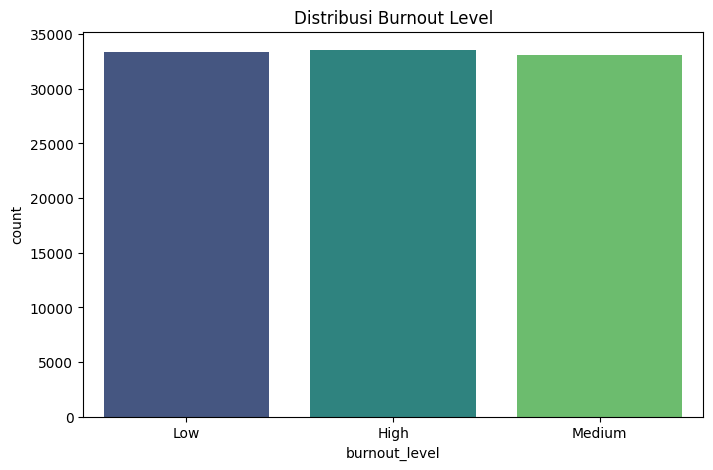

In [2]:
print(f"Shape dataset: {df.shape}")
print(f"Jumlah data: {len(df)}")
print(f"Jumlah fitur: {df.shape[1] - 1}")
display(df.info())
display(df.describe())
display(df.head())
display(df.tail())

# Distribusi Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='burnout_level', palette='viridis')
plt.title('Distribusi Burnout Level')
plt.show()

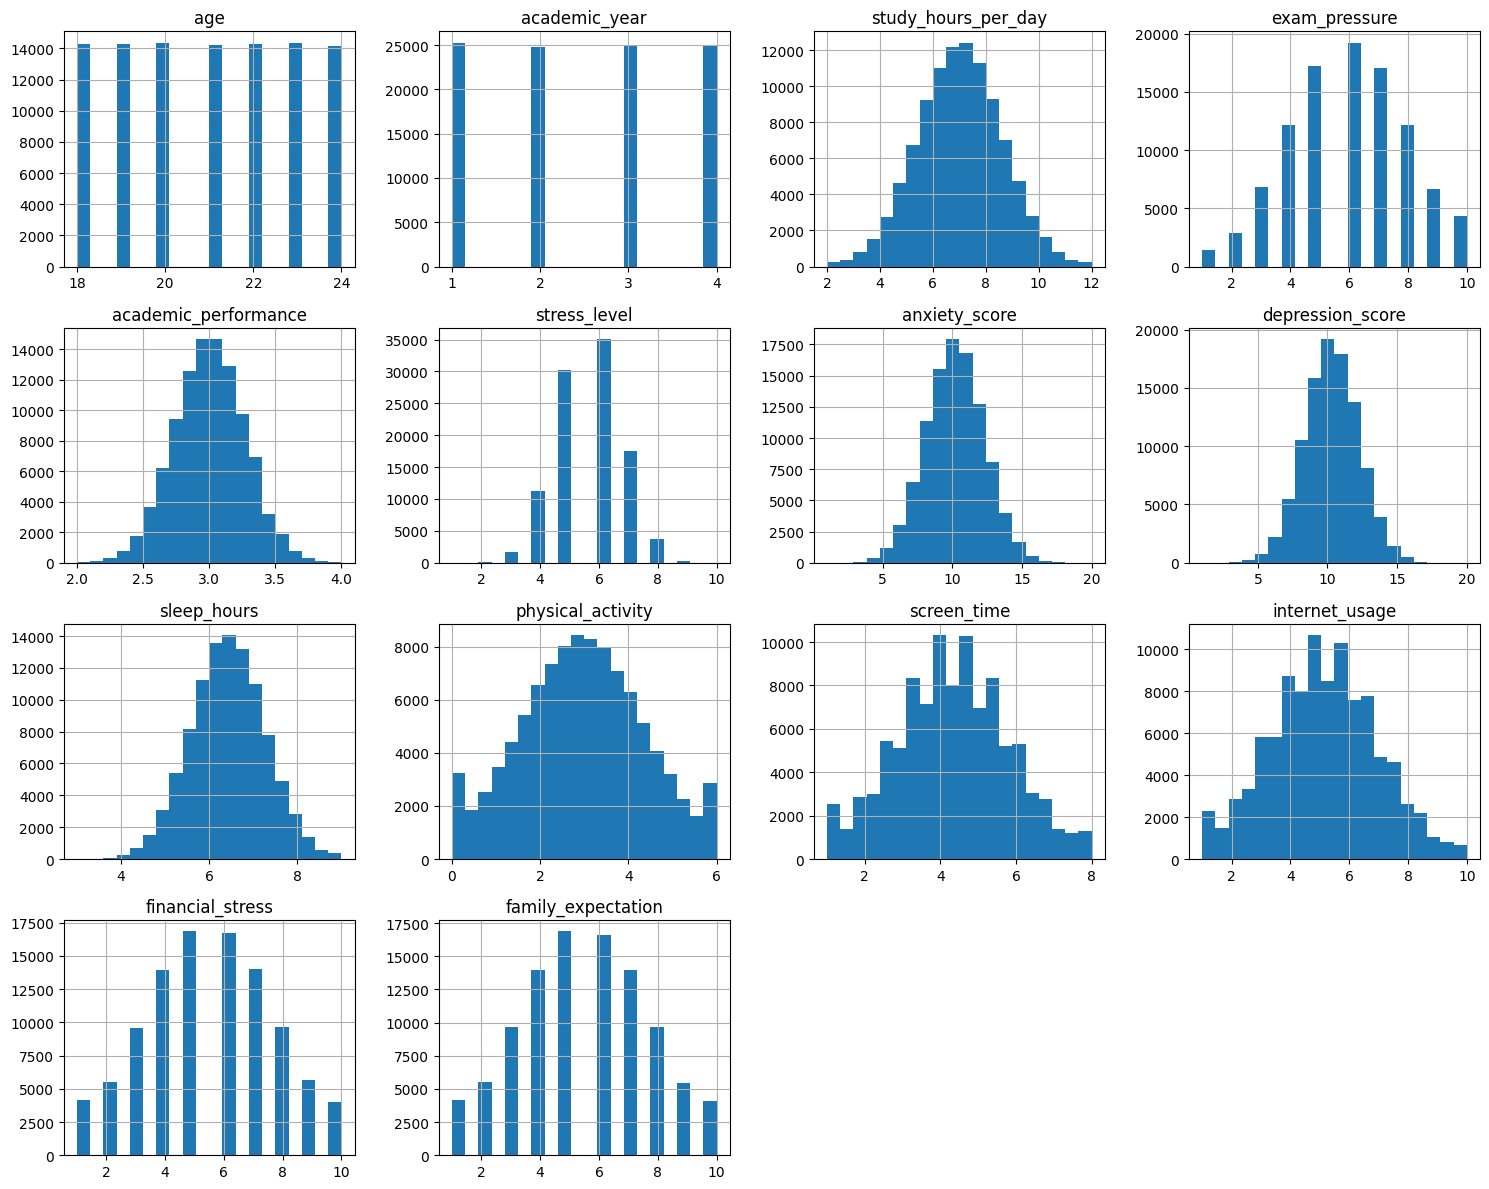

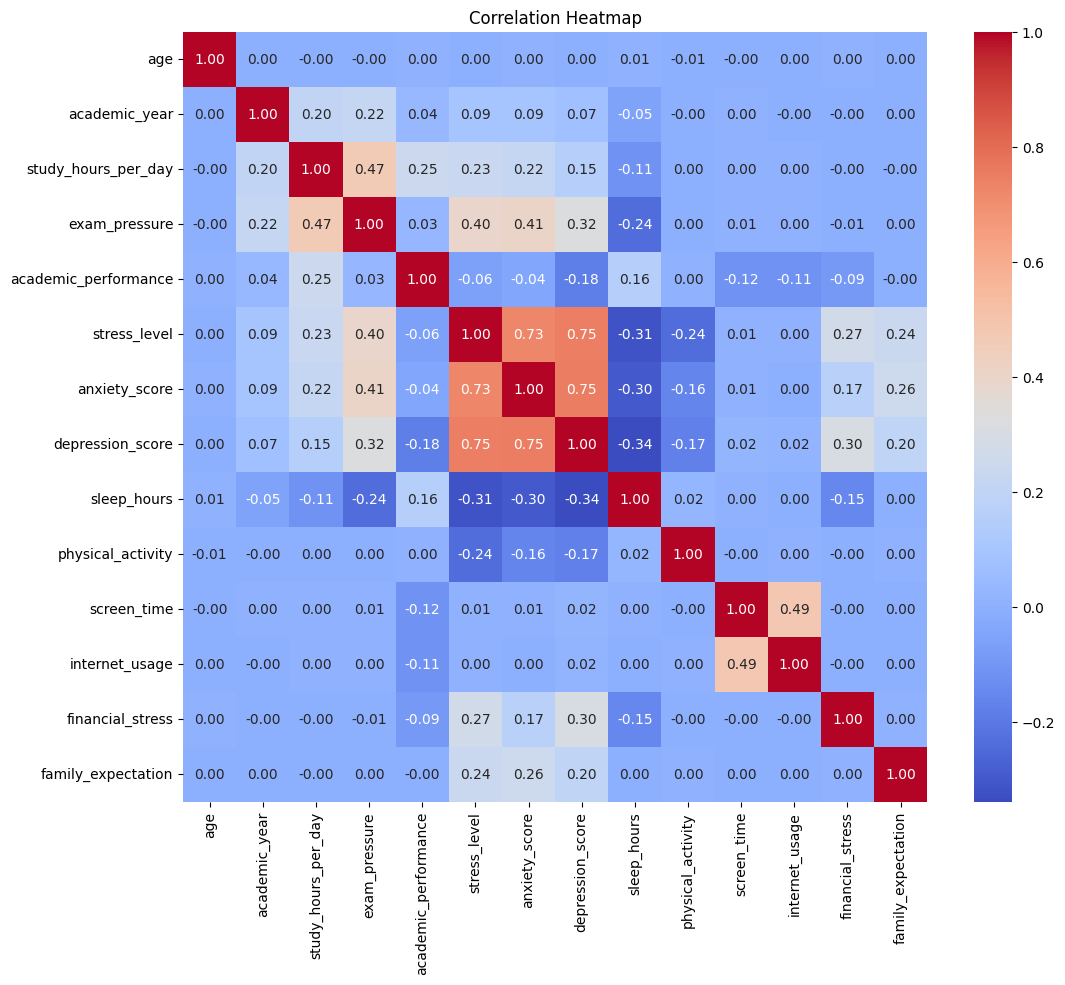

In [3]:
# Visualisasi Fitur Numerik
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

# Heatmap Korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## SECTION 3: Data Preprocessing

Melakukan pembersihan data dan encoding fitur kategorikal.

In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Inisialisasi Encoders
le_gender = LabelEncoder()
le_social = LabelEncoder()
le_burnout = LabelEncoder()

# Encoding
df['gender'] = le_gender.fit_transform(df['gender'])
df['social_support'] = le_social.fit_transform(df['social_support'])
df['burnout_level'] = le_burnout.fit_transform(df['burnout_level'])

# Memisahkan Fitur dan Target
X = df.drop('burnout_level', axis=1)
y = df['burnout_level']

print("Preprocessing selesai.")

Missing Values:
 age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_level           0
dtype: int64

Duplicate Rows: 0
Preprocessing selesai.


## SECTION 4: Dataset Splitting

Membagi data menjadi set pelatihan (80%) dan set pengujian (20%).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data Training: {X_train.shape[0]} samples")
print(f"Data Testing: {X_test.shape[0]} samples")

Data Training: 80000 samples
Data Testing: 20000 samples


## SECTION 5 & 6: Random Forest Model Development & Prediction

In [6]:
# Inisialisasi Model Awal
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

## SECTION 7: Model Evaluation & Hyperparameter Tuning

--- Random Forest Awal ---
Accuracy: 0.6421
              precision    recall  f1-score   support

           0       0.72      0.71      0.72      6710
           1       0.71      0.71      0.71      6677
           2       0.50      0.50      0.50      6613

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



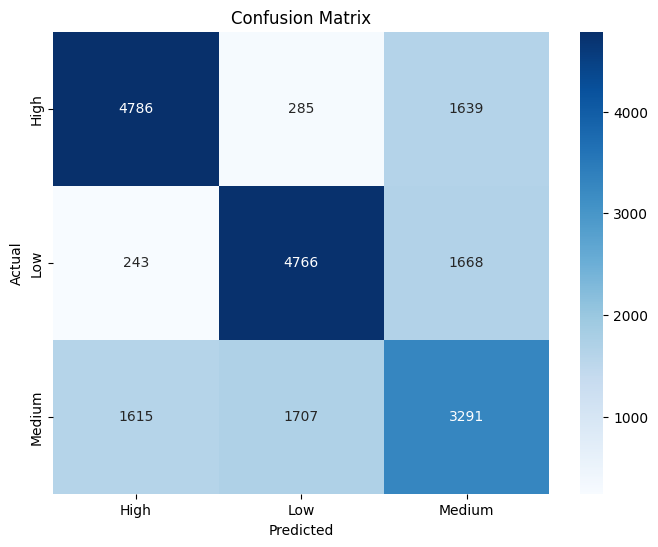

In [7]:
def evaluate(y_true, y_pred, model_name="Model"):
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))

evaluate(y_test, y_pred, "Random Forest Awal")

# Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_burnout.classes_, yticklabels=le_burnout.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [8]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Params: {grid_search.best_params_}")

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


## SECTION 8: Model Saving

Menyimpan model dan encoder untuk digunakan di Streamlit.

In [9]:
import os
os.makedirs('output', exist_ok=True)

joblib.dump(best_rf, 'output/random_forest_model.pkl')
joblib.dump(le_gender, 'output/gender_encoder.pkl')
joblib.dump(le_social, 'output/social_support_encoder.pkl')
joblib.dump(le_burnout, 'output/burnout_encoder.pkl')

print("Seluruh model dan encoder telah disimpan di folder 'output'.")

Seluruh model dan encoder telah disimpan di folder 'output'.


## SECTION 9: Streamlit Implementation

File di folder `output` siap digunakan pada aplikasi `app.py`. Anda perlu memuat model tersebut menggunakan `joblib.load()` di script Streamlit Anda.

## SECTION 10: Research Summary

In [10]:
y_best_pred = best_rf.predict(X_test)
cv_acc = cross_val_score(best_rf, X, y, cv=5).mean()

print("=== RINGKASAN PENELITIAN ===")
print(f"Jumlah Data: {len(df)}")
print(f"Akurasi Model Terbaik: {accuracy_score(y_test, y_best_pred):.4f}")
print(f"Cross Validation Accuracy: {cv_acc:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")
print("Kesimpulan: Model Random Forest menunjukkan performa yang stabil dalam memprediksi tingkat burnout mahasiswa.")

=== RINGKASAN PENELITIAN ===
Jumlah Data: 100000
Akurasi Model Terbaik: 0.6431
Cross Validation Accuracy: 0.6427
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Kesimpulan: Model Random Forest menunjukkan performa yang stabil dalam memprediksi tingkat burnout mahasiswa.
